# Predicting Cancer Metastasis from Gene Expression

### Install XGBoost and load libraries

In [7]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


### Load Libraries

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_classif
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)

from xgboost import XGBClassifier

### Load Data

In [26]:
cm = pd.read_csv('Breast_GSE45827.csv')

In [27]:
cm.head()

,samples,type,1007_s_at,1053_at,117_at,121_at,1255_g_at,1294_at,1316_at,1320_at,...,AFFX-r2-Ec-bioD-3_at,AFFX-r2-Ec-bioD-5_at,AFFX-r2-P1-cre-3_at,AFFX-r2-P1-cre-5_at,AFFX-ThrX-3_at,AFFX-ThrX-5_at,AFFX-ThrX-M_at,AFFX-TrpnX-3_at,AFFX-TrpnX-5_at,AFFX-TrpnX-M_at
0,84,basal,9.850040,8.097927,6.424728,7.353027,3.029122,6.880079,4.963740,4.408328,...,12.229711,11.852955,13.658701,13.477698,6.265781,5.016196,4.901594,2.966657,3.508495,3.301999
1,85,basal,9.861357,8.212222,7.062593,7.685578,3.149468,7.542283,5.129607,4.584418,...,12.178531,11.809408,13.750086,13.470146,6.771853,5.291005,5.405839,2.934763,3.687666,3.064299
2,87,basal,10.103478,8.936137,5.735970,7.687822,3.125931,6.562369,4.813449,4.425195,...,12.125108,11.725766,13.621732,13.295080,6.346952,5.171403,5.184286,2.847684,3.550597,3.158535
3,90,basal,9.756875,7.357148,6.479183,6.986624,3.181638,7.802344,5.490982,4.567956,...,12.111235,11.719215,13.743108,13.508861,6.610284,5.193356,5.086569,3.031602,3.524981,3.272665
4,91,basal,9.408330,7.746404,6.693980,7.333426,3.169923,7.610457,5.372469,4.424426,...,12.173642,11.861296,13.797774,13.542206,6.414354,5.040202,5.235318,2.956232,3.445501,3.193947


In [46]:
cm.shape

(151, 54677)

<Axes: xlabel='count', ylabel='type'>

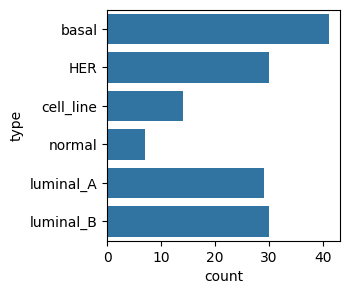

In [28]:
plt.figure(figsize=(3,3))
sns.countplot(cm['type'])

In [29]:
cm['type'].unique()

array(['basal', 'HER', 'cell_line', 'normal', 'luminal_A', 'luminal_B'],
      dtype=object)

In [30]:
# Target
y = cm["type"].astype(str)

# Features: drop ID + label columns
X = cm.drop(columns=["samples", "type"])

print("X shape:", X.shape)
print("Classes:", sorted(y.unique()))

X shape: (151, 54675)
Classes: ['HER', 'basal', 'cell_line', 'luminal_A', 'luminal_B', 'normal']


### Train test split

In [31]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

In [32]:
X_train.shape

(105, 54675)

In [33]:
X_test.shape

(46, 54675)

In [47]:
y_test.head()

88        normal
27         basal
118    luminal_A
117    luminal_A
127    luminal_B
Name: type, dtype: object

### Encode Labels

In [35]:
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

print("Class mapping:", dict(zip(le.classes_, le.transform(le.classes_))))

Class mapping: {'HER': np.int64(0), 'basal': np.int64(1), 'cell_line': np.int64(2), 'luminal_A': np.int64(3), 'luminal_B': np.int64(4), 'normal': np.int64(5)}


In [36]:
y_train_enc

array([5, 0, 4, 3, 0, 0, 0, 4, 0, 1, 2, 1, 1, 2, 3, 3, 0, 0, 4, 1, 4, 0,
       0, 4, 1, 1, 4, 3, 0, 1, 5, 4, 1, 4, 2, 1, 4, 0, 3, 1, 3, 1, 4, 4,
       1, 3, 0, 3, 2, 3, 0, 1, 0, 4, 2, 1, 5, 1, 3, 3, 5, 2, 4, 4, 1, 4,
       2, 1, 3, 0, 3, 3, 0, 3, 1, 0, 3, 3, 4, 1, 1, 4, 4, 0, 2, 3, 1, 1,
       3, 1, 4, 2, 3, 1, 0, 1, 1, 1, 0, 1, 4, 0, 4, 2, 5])

### Scaling the dataset

In [37]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [38]:
X_train_scaled.shape

(105, 54675)

In [39]:
X_test_scaled.shape

(46, 54675)

### Feature Selection

Remove low-variance genes: Genes with almost no variation across all samples.

In [40]:
var_filter = VarianceThreshold(threshold=0.01)  # adjust if needed
X_train_var = var_filter.fit_transform(X_train)
X_test_var = var_filter.transform(X_test)

print("After variance filter:", X_train_var.shape)

After variance filter: (105, 54599)


This is a “cheap” filter that removes genes that can’t separate classes because they barely vary

Let us now use the univariate ANOVA F-test Selector

In [41]:
k = 100  # try 500, 1000, 2000, 5000 depending on sample size
selector = SelectKBest(score_func=f_classif, k=k)

X_train_sel = selector.fit_transform(X_train_var, y_train_enc)
X_test_sel = selector.transform(X_test_var)

print("After SelectKBest:", X_train_sel.shape)

After SelectKBest: (105, 100)


### Train XGBoost

In [42]:
num_classes = len(le.classes_)

model = XGBClassifier(
    objective="multi:softprob",
    num_class=num_classes,
    n_estimators=600,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
    eval_metric="mlogloss"
)

model.fit(X_train_sel, y_train_enc)

,objective,'multi:softprob'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'mlogloss'


### Evaluate Model

In [43]:
y_pred_enc = model.predict(X_test_sel)
y_pred = le.inverse_transform(y_pred_enc)

print(classification_report(y_test, y_pred, digits=3))

              precision    recall  f1-score   support

         HER      1.000     1.000     1.000         9
       basal      0.917     0.846     0.880        13
   cell_line      0.750     0.750     0.750         4
   luminal_A      0.889     0.889     0.889         9
   luminal_B      0.800     0.889     0.842         9
      normal      1.000     1.000     1.000         2

    accuracy                          0.891        46
   macro avg      0.893     0.896     0.893        46
weighted avg      0.894     0.891     0.892        46



### Feature Importance

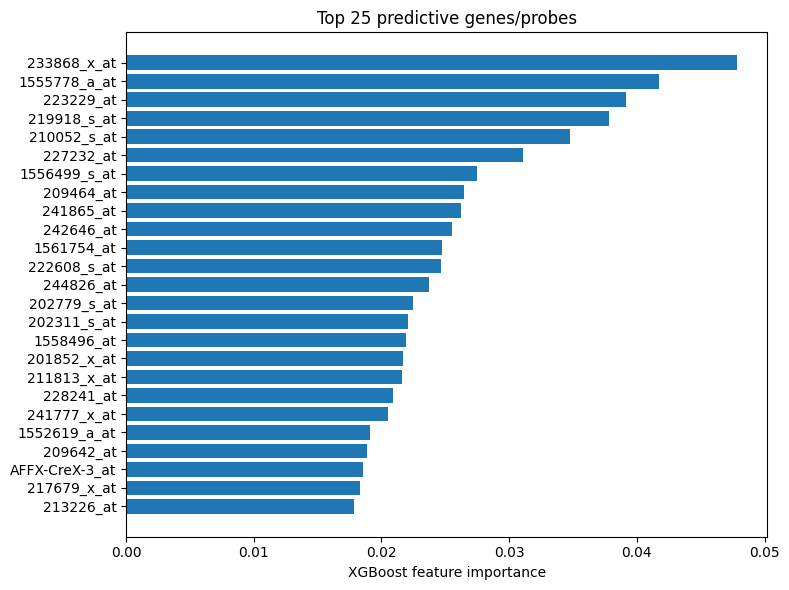

In [44]:
# Get feature names surviving variance filter
feature_names_after_var = X_train.columns[var_filter.get_support()]

# Get feature names selected by SelectKBest
selected_feature_names = feature_names_after_var[selector.get_support()]

importances = model.feature_importances_
top_n = 25
top_idx = np.argsort(importances)[-top_n:]

plt.figure(figsize=(8, 6))
plt.barh(selected_feature_names[top_idx], importances[top_idx])
plt.xlabel("XGBoost feature importance")
plt.title(f"Top {top_n} predictive genes/probes")
plt.tight_layout()
plt.show()

In [45]:
selected_feature_names[top_idx]

Index(['213226_at', '217679_x_at', 'AFFX-CreX-3_at', '209642_at',
       '1552619_a_at', '241777_x_at', '228241_at', '211813_x_at',
       '201852_x_at', '1558496_at', '202311_s_at', '202779_s_at', '244826_at',
       '222608_s_at', '1561754_at', '242646_at', '241865_at', '209464_at',
       '1556499_s_at', '227232_at', '210052_s_at', '219918_s_at', '223229_at',
       '1555778_a_at', '233868_x_at'],
      dtype='object')